<a href="https://colab.research.google.com/github/chinmayisanjeevarao-crypto/ShadowFox/blob/main/Copy_of_Loan_Approval_Prediction_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
from google.colab import files

# Upload the dataset
uploaded = files.upload()


Saving train.csv to train.csv


In [3]:
# Load the dataset
df = pd.read_csv("train.csv")

# Show first 5 rows
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Info about columns
print("\nDataset info:")
print(df.info())

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Dataset shape: (614, 13)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None

Missing values per column:
Loan_ID               0
Gender         

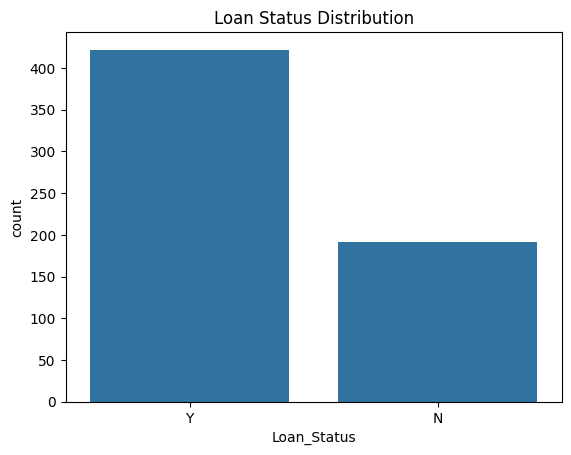

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [5]:
# Loan_Status is the target column
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

print(df['Loan_Status'].value_counts())


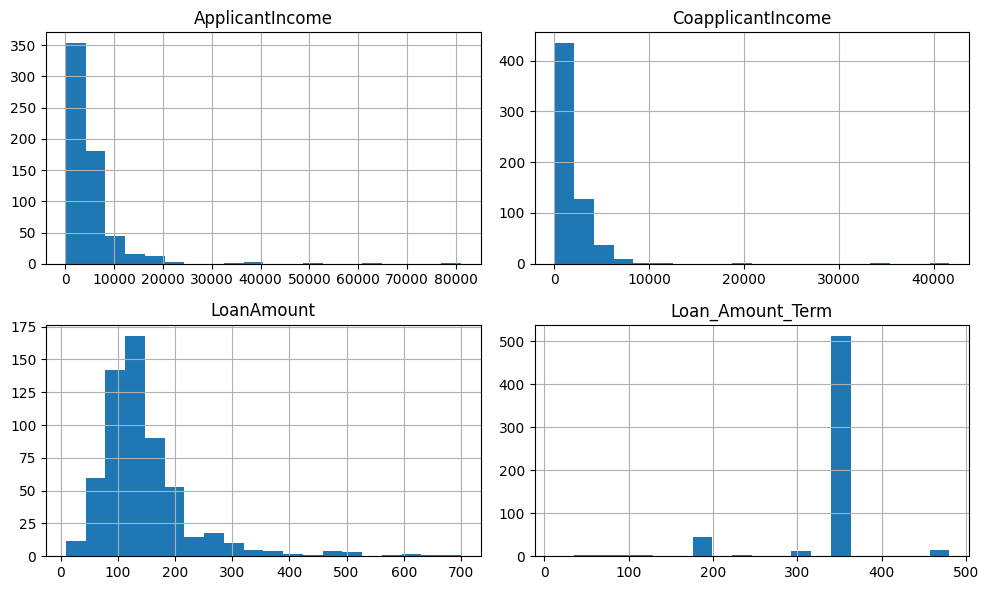

In [6]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

df[num_cols].hist(bins=20, figsize=(10,6))
plt.tight_layout()
plt.show()


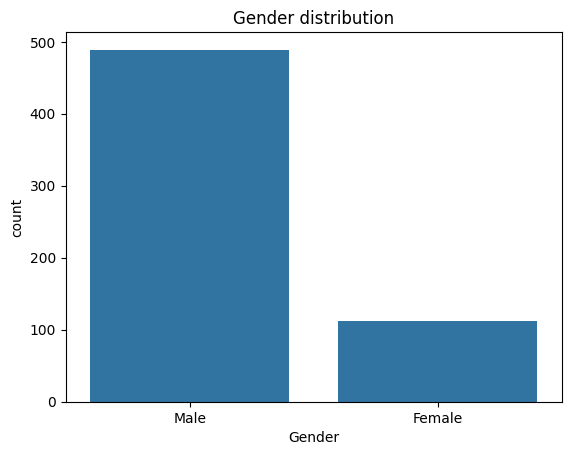

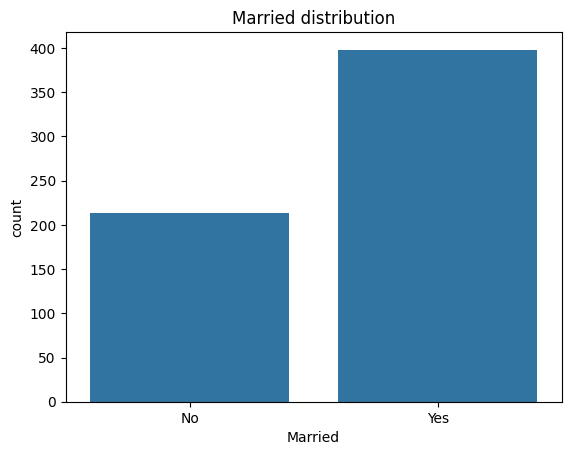

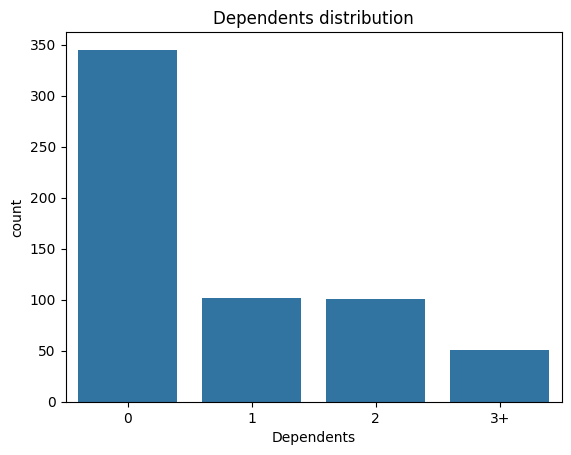

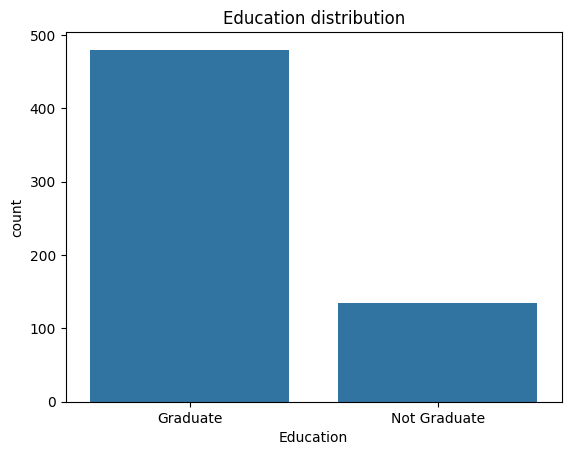

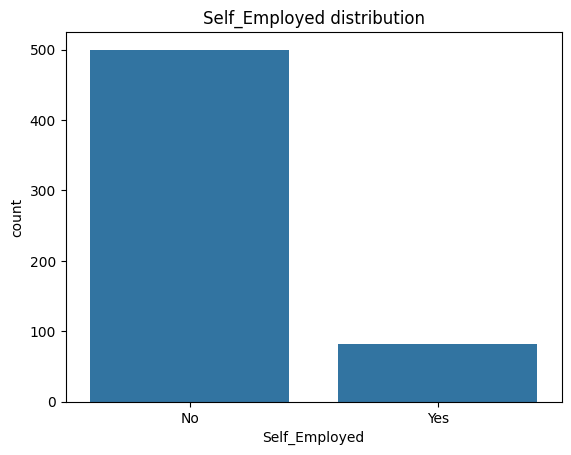

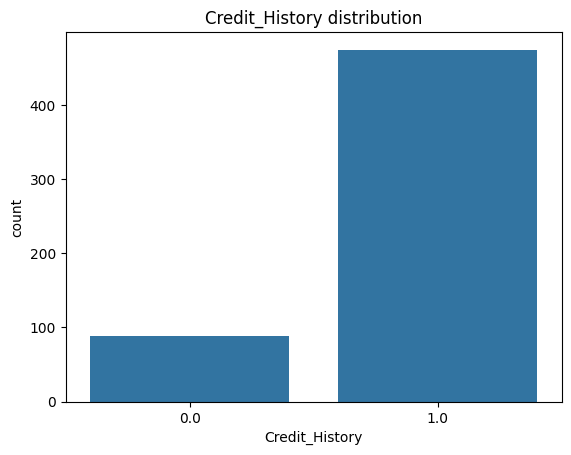

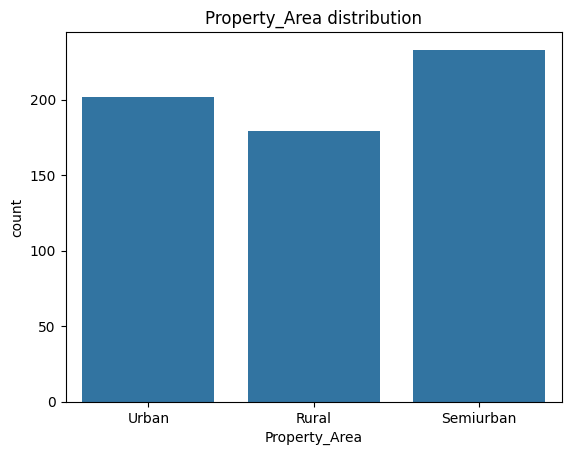

In [7]:
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Credit_History','Property_Area']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"{col} distribution")
    plt.show()


In [8]:
# Fill categorical missing values with mode
for col in ['Gender','Married','Dependents','Self_Employed','Credit_History']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numerical missing values with median
for col in ['LoanAmount','Loan_Amount_Term']:
    df[col].fillna(df[col].median(), inplace=True)

print("✅ Missing values handled")
print(df.isnull().sum())


✅ Missing values handled
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipython-input-3866259713.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-3866259713.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [9]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical features encoded")
df.head()


✅ Categorical features encoded


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [10]:
# Features and target
X = df.drop(columns=['Loan_ID','Loan_Status'])
y = df['Loan_Status']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (614, 11)
Target shape: (614,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 491
Testing samples: 123


In [12]:
# Step 5: Model Training and Evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd

# Assuming X_train, X_test, y_train, y_test are already prepared

# 1️⃣ Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

# 2️⃣ Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3️⃣ Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n=== {model_name} Evaluation ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# 4️⃣ Evaluate both models
evaluate_model(y_test, y_pred_logreg, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

# 5️⃣ Optional: Compare results in a DataFrame
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_logreg), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_logreg, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted')],
    'Recall': [recall_score(y_test, y_pred_logreg, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted')],
    'F1 Score': [f1_score(y_test, y_pred_logreg, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted')]
})

print("\n=== Model Comparison ===")
print(results)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression Evaluation ===
Accuracy: 0.8617886178861789
Precision: 0.8759985860728171
Recall: 0.8617886178861789
F1 Score: 0.850398579307016
Confusion Matrix:
 [[22 16]
 [ 1 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


=== Random Forest Evaluation ===
Accuracy: 0.8292682926829268
Precision: 0.8250778230082441
Recall: 0.8292682926829268
F1 Score: 0.8239840393982423
Confusion Matrix:
 [[24 14]
 [ 7 78]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.63      0.70        38
           1       0.85      0.92      0.88        85

    accuracy                           0.83       123
   macro avg       0.81     

In [13]:
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],  # lbfgs works only with 'l2'
    'penalty': ['l2']                  # only l2 allowed for lbfgs
}


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Top 10 Feature Importances:
 Credit_History       0.242296
ApplicantIncome      0.209001
LoanAmount           0.192555
CoapplicantIncome    0.113800
Dependents           0.053360
Property_Area        0.048456
Loan_Amount_Term     0.048202
Married              0.027660
Education            0.027166
Gender               0.019237
dtype: float64


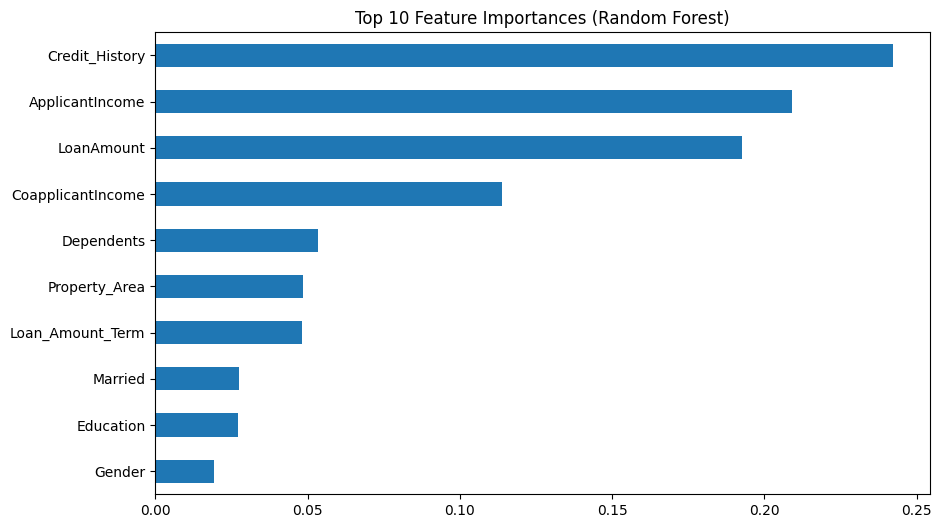

In [15]:
# Step 7: Feature Importance (Random Forest) - Ready to Run

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Make sure X_train and y_train are defined (DataFrame preferred)
# If using numpy arrays, replace feature_names with a list of column names

# 1️⃣ Train a Random Forest (simple version)
rf_simple = RandomForestClassifier(n_estimators=100, random_state=42)
rf_simple.fit(X_train, y_train)

# 2️⃣ Get feature importances
importances = rf_simple.feature_importances_
feature_names = X_train.columns  # or a list if X_train is numpy
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 3️⃣ Show top 10 features
print("Top 10 Feature Importances:\n", feat_importances.head(10))

# 4️⃣ Plot top 10
plt.figure(figsize=(10,6))
feat_importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


In [16]:
# Step 8: Save & Load Final Model

from sklearn.ensemble import RandomForestClassifier
import joblib

# 1️⃣ Train a Random Forest (simple version)
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)  # make sure X_train, y_train are defined

# 2️⃣ Save the trained model
joblib.dump(rf_final, "final_model_rf.pkl")
print("Random Forest model saved as 'final_model_rf.pkl'")

# 3️⃣ Load the model later for predictions
loaded_model = joblib.load("final_model_rf.pkl")
print("Model loaded successfully!")

# 4️⃣ Example: Predict on new data
# new_data must have the same features as X_train
# predictions = loaded_model.predict(new_data)
# print(predictions)


Random Forest model saved as 'final_model_rf.pkl'
Model loaded successfully!


In [17]:
import joblib

# Load your saved model
model = joblib.load("final_model_rf.pkl")


In [18]:
# Example: new_data is a DataFrame with the same columns as X_train
# new_data = pd.DataFrame({...})


In [19]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1️⃣ Define categorical and numerical columns
categorical_features = ['Gender', 'Married', 'Education', 'Dependents', 'Property_Area', 'Self_Employed']
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# 2️⃣ Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# 3️⃣ Create pipeline with preprocessing + Random Forest
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 4️⃣ Fit the pipeline on training data
pipeline.fit(X_train, y_train)  # X_train = raw training data (not encoded)

# 5️⃣ Save the pipeline
joblib.dump(pipeline, "final_pipeline.pkl")

# 6️⃣ Load the pipeline and predict on new raw data
loaded_pipeline = joblib.load("final_pipeline.pkl")

new_data = pd.DataFrame([{
    'Gender': 'Male',
    'Married': 'Yes',
    'Education': 'Graduate',
    'Dependents': '0',
    'Property_Area': 'Urban',
    'Self_Employed': 'No',
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1
}])

predictions = loaded_pipeline.predict(new_data)
probs = loaded_pipeline.predict_proba(new_data)

print("Predicted class:", predictions[0])
print("Prediction probabilities:", probs)


Predicted class: 1
Prediction probabilities: [[0.22 0.78]]


In [20]:
# Example: compare predictions on new batches vs expected
from sklearn.metrics import accuracy_score

# y_true_new = actual labels for new batch
# predictions_new = model.predict(new_batch)
# accuracy = accuracy_score(y_true_new, predictions_new)
# print("New batch accuracy:", accuracy)


In [21]:
joblib.dump(pipeline, "final_pipeline_v2.pkl")


['final_pipeline_v2.pkl']

In [22]:
import joblib

# Save entire pipeline
joblib.dump(loaded_pipeline, "final_pipeline.pkl")

# Load pipeline later
pipeline = joblib.load("final_pipeline.pkl")
predictions = pipeline.predict(new_data)


In [23]:
import joblib

# Save the pipeline (preprocessor + classifier)
joblib.dump(loaded_pipeline, "final_pipeline.pkl")


['final_pipeline.pkl']

In [24]:
# Load pipeline when needed
pipeline = joblib.load("final_pipeline.pkl")

# Predict on new data
predictions = pipeline.predict(new_data)
prediction_probs = pipeline.predict_proba(new_data)
print("Predictions:", predictions)
print("Prediction probabilities:", prediction_probs)


Predictions: [1]
Prediction probabilities: [[0.22 0.78]]


In [25]:
def predict_loan_status(new_data_df):
    """
    Predict class and probability for new loan applications.
    new_data_df: pd.DataFrame with raw input features (before preprocessing)
    """
    pipeline = joblib.load("final_pipeline.pkl")
    pred_class = pipeline.predict(new_data_df)
    pred_prob = pipeline.predict_proba(new_data_df)
    return pred_class, pred_prob


In [26]:
import joblib
import shap
import numpy as np
import pandas as pd

# Load pipeline (preprocessor + classifier)
pipeline = joblib.load("final_pipeline.pkl")

def predict_with_shap(new_data):
    """
    Input: new_data as a DataFrame (raw features, same as training input)
    Output: predictions, probabilities, and SHAP Explanation object
    """
    # 1️⃣ Transform new data
    X_transformed = pipeline.named_steps['preprocessor'].transform(new_data)

    # 2️⃣ Predict class and probability
    predictions = pipeline.predict(new_data)
    probabilities = pipeline.predict_proba(new_data)

    # 3️⃣ Get feature names after preprocessing
    num_features = pipeline.named_steps['preprocessor'].transformers_[0][2]
    ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_features = ohe.get_feature_names_out(pipeline.named_steps['preprocessor'].transformers_[1][2])
    feature_names = np.concatenate([num_features, cat_features])

    # 4️⃣ Explain predictions with SHAP
    classifier = pipeline.named_steps['classifier']
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer(X_transformed)

    return predictions, probabilities, shap_values, feature_names


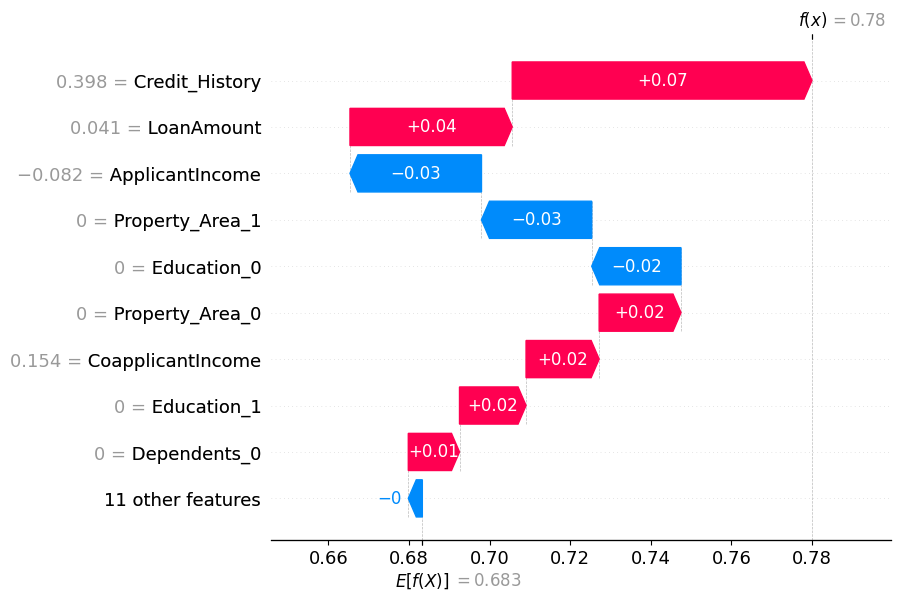

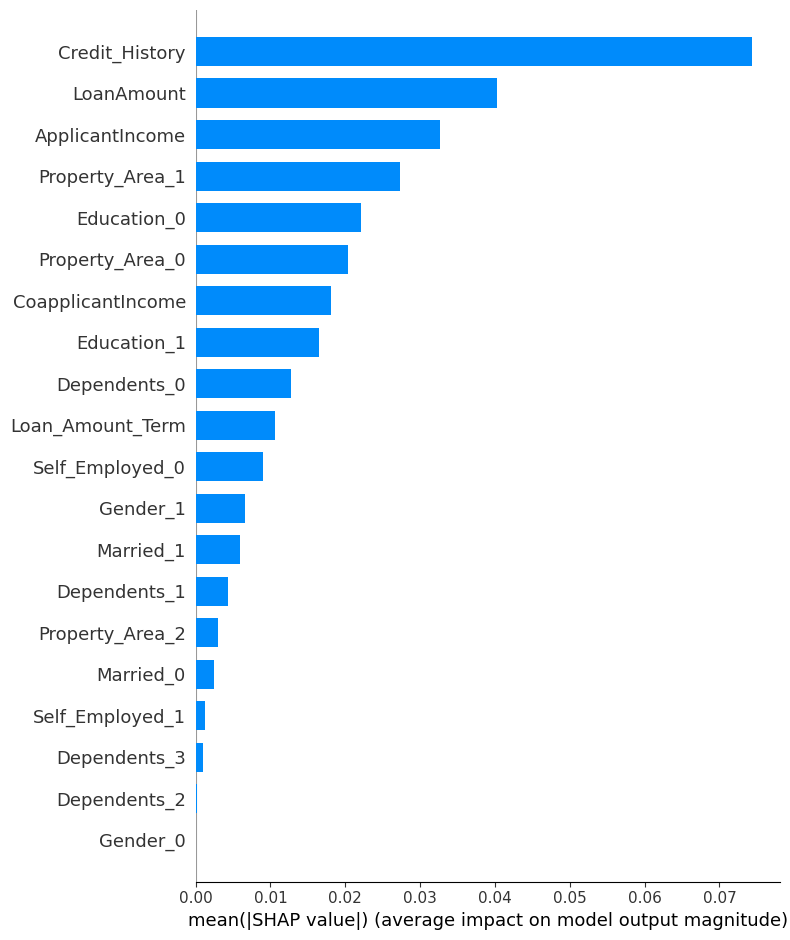

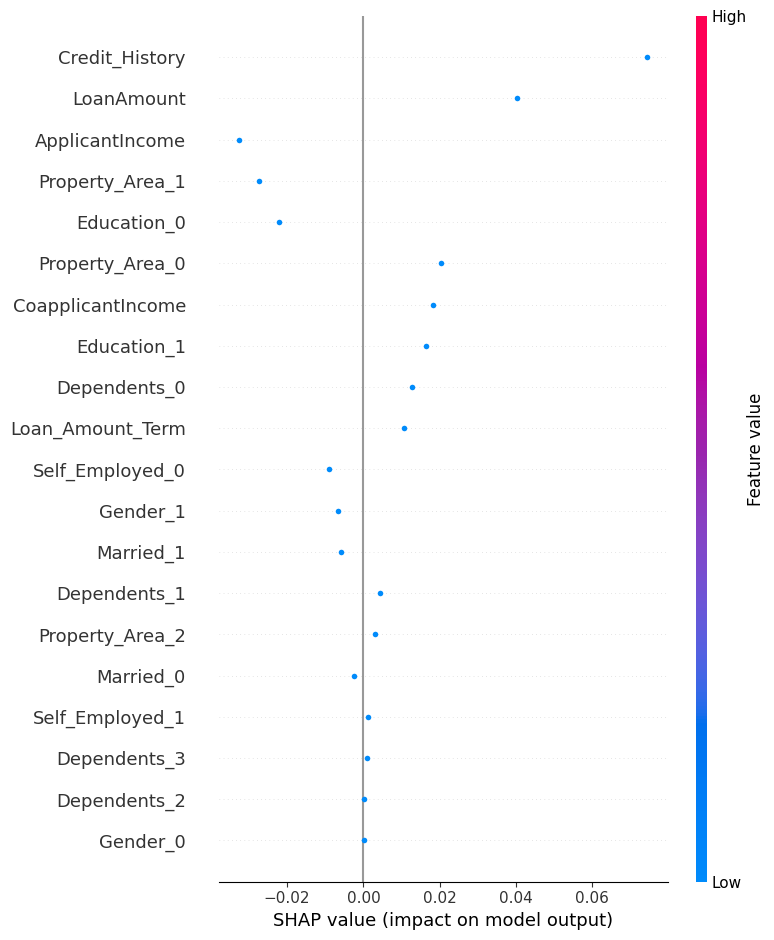

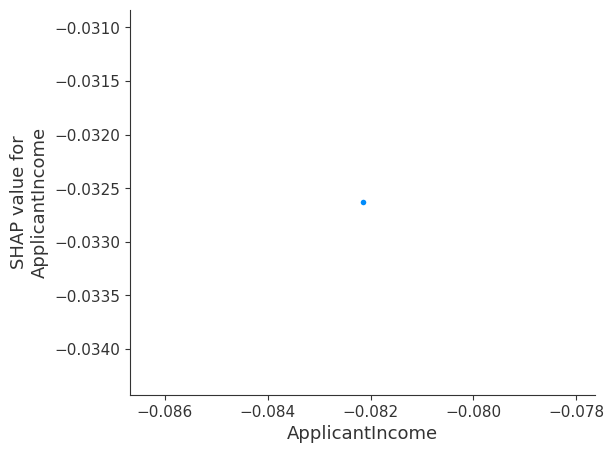

In [31]:
import pandas as pd
import numpy as np
import joblib
import shap

# 1️⃣ Load your saved pipeline
pipeline = joblib.load("final_pipeline.pkl")

# 2️⃣ Prepare new data (must include all columns used in training)
new_data = pd.DataFrame([{
    'Gender': 'Male',
    'Married': 'Yes',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Dependents': '0',
    'Property_Area': 'Urban'
}])

# 3️⃣ Transform new data
preprocessor = pipeline.named_steps['preprocessor']
X_transformed = preprocessor.transform(new_data)

# 4️⃣ Get feature names after preprocessing
num_features = preprocessor.transformers_[0][2]  # numeric columns
ohe = preprocessor.named_transformers_['cat']
cat_features = ohe.get_feature_names_out(preprocessor.transformers_[1][2])
feature_names = np.concatenate([num_features, cat_features])

# 5️⃣ SHAP explanation
classifier = pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(classifier)
shap_values_all = explainer(X_transformed)  # shap.Explanation object

# 6️⃣ Select class 1 (positive class) for binary classification
if shap_values_all.values.ndim == 3:  # (samples, features, classes)
    shap_values_class1 = shap.Explanation(
        values=shap_values_all.values[:, :, 1],
        base_values=shap_values_all.base_values[:, 1],
        data=X_transformed,
        feature_names=feature_names
    )
else:
    shap_values_class1 = shap_values_all

# 7️⃣ Waterfall plot for the first sample
shap.plots.waterfall(shap_values_class1[0])

# 8️⃣ Global summary plots
shap.summary_plot(shap_values_class1.values, X_transformed, feature_names=feature_names, plot_type="bar")
shap.summary_plot(shap_values_class1.values, X_transformed, feature_names=feature_names)

# 9️⃣ Dependence plot (example for ApplicantIncome)
shap.dependence_plot(
    "ApplicantIncome",
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names
)


In [32]:
# Interactive force plot for the first sample
shap.initjs()
shap.force_plot(
    base_value=shap_values_class1.base_values[0],  # base value for first sample
    shap_values=shap_values_class1.values[0],      # SHAP values for first sample
    features=X_transformed[0],                     # feature values for first sample
    feature_names=feature_names                    # feature names
)



--- SHAP Waterfall for Sample 1 ---


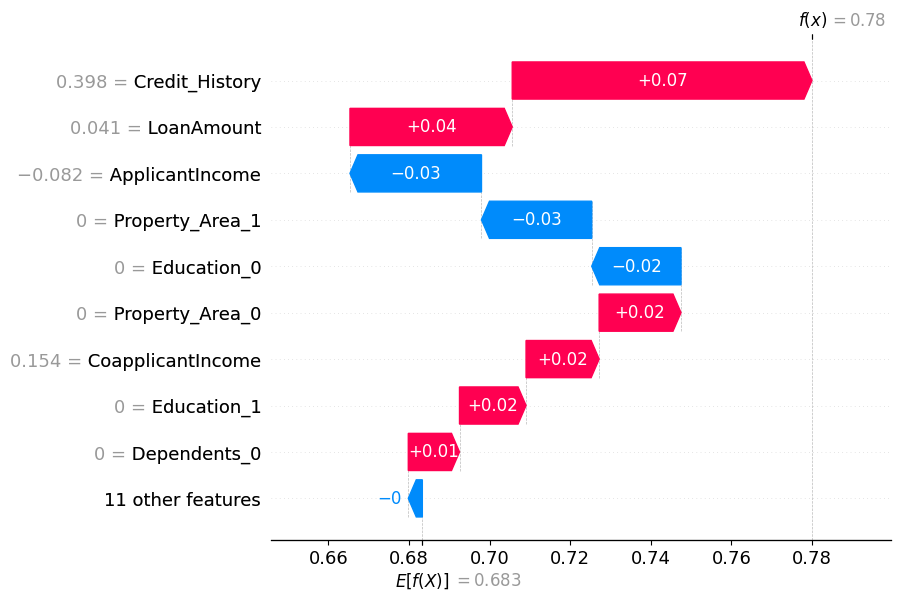

In [33]:
for i in range(X_transformed.shape[0]):
    print(f"\n--- SHAP Waterfall for Sample {i+1} ---")
    shap.plots.waterfall(shap_values_class1[i])


In [34]:
import pandas as pd

# For first sample
shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_value": shap_values_class1.values[0]
}).sort_values(by="SHAP_value", key=abs, ascending=False)

print(shap_df.head(5))  # Top 5 impactful features


            Feature  SHAP_value
4    Credit_History    0.074375
2        LoanAmount    0.040259
0   ApplicantIncome   -0.032630
16  Property_Area_1   -0.027356
9       Education_0   -0.022150


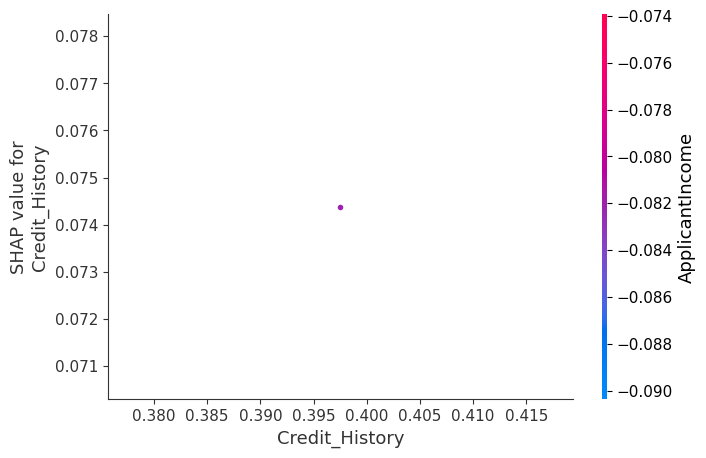

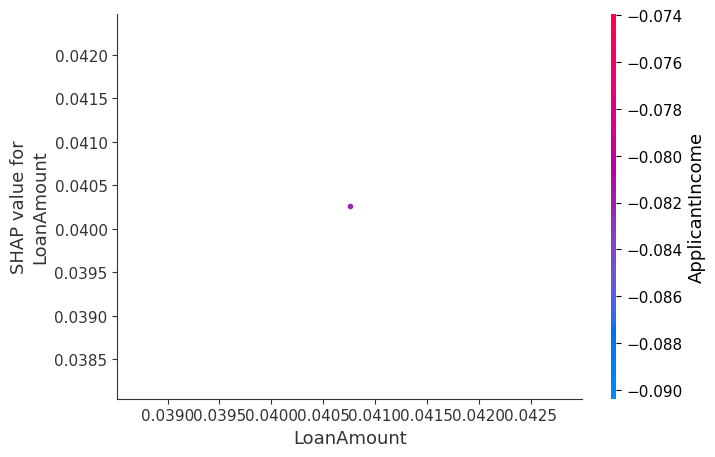

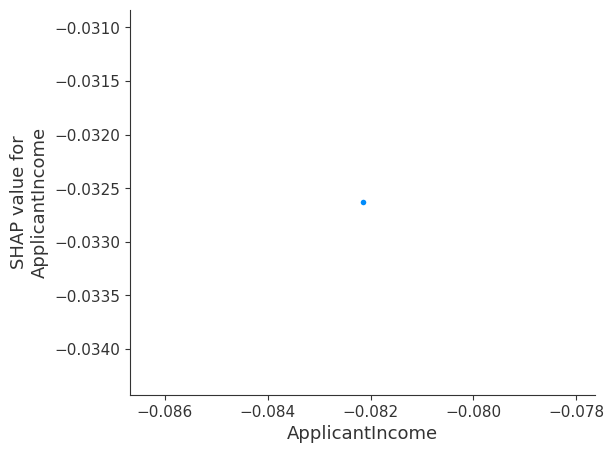

In [35]:
top_features = shap_df['Feature'].head(3).tolist()  # top 3 features
for f in top_features:
    shap.dependence_plot(f, shap_values_class1.values, X_transformed, feature_names=feature_names)



=== Analysis for Sample 1 ===
Waterfall Plot:


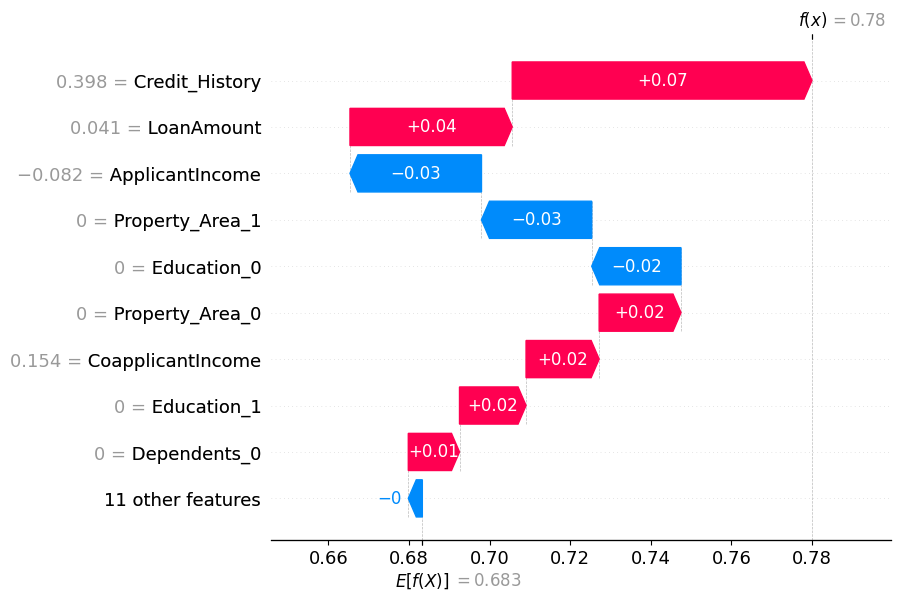


Top 5 Contributing Features:
            Feature  SHAP_value
4    Credit_History    0.074375
2        LoanAmount    0.040259
0   ApplicantIncome   -0.032630
16  Property_Area_1   -0.027356
9       Education_0   -0.022150
Interactive Force Plot:



=== Global Feature Importance ===


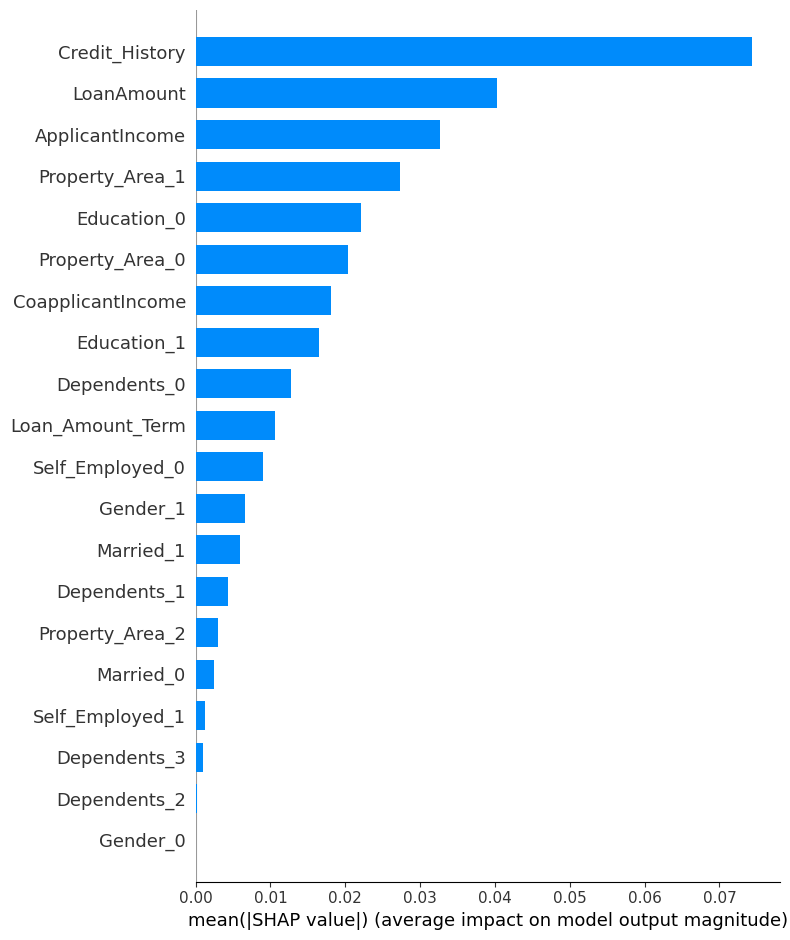

In [36]:
import pandas as pd
import shap

# 1️⃣ Initialize JS for interactive plots
shap.initjs()

# 2️⃣ Loop through each new sample
for i in range(X_transformed.shape[0]):
    print(f"\n=== Analysis for Sample {i+1} ===")

    # 🔹 Waterfall plot (individual feature contribution)
    print("Waterfall Plot:")
    shap.plots.waterfall(shap_values_class1[i])

    # 🔹 Top 5 features contributing to prediction
    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_value": shap_values_class1.values[i]
    }).sort_values(by="SHAP_value", key=abs, ascending=False)

    print("\nTop 5 Contributing Features:")
    print(shap_df.head(5))

    # 🔹 Optional: Interactive Force plot
    print("Interactive Force Plot:")
    display(
        shap.force_plot(
            base_value=shap_values_class1.base_values[i],
            shap_values=shap_values_class1.values[i],
            features=X_transformed[i],
            feature_names=feature_names
        )
    )

# 3️⃣ Global summary plot for all new samples
print("\n=== Global Feature Importance ===")
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)


In [38]:
import os
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 1️⃣ Create folder for reports
report_dir = "shap_reports"
os.makedirs(report_dir, exist_ok=True)

# 2️⃣ Loop through each sample
for i in range(X_transformed.shape[0]):
    sample_id = i + 1
    report_path = os.path.join(report_dir, f"sample_{sample_id}_shap_report.html")

    # 🔹 Waterfall plot (PNG)
    plt.figure(figsize=(10,6))
    shap.plots.waterfall(shap_values_class1[i], show=False)
    waterfall_path = os.path.join(report_dir, f"sample_{sample_id}_waterfall.png")
    plt.savefig(waterfall_path, bbox_inches='tight')
    plt.close()

    # 🔹 Top 5 features
    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_value": shap_values_class1.values[i]
    }).sort_values(by="SHAP_value", key=abs, ascending=False)
    top_features = shap_df.head(5)

    # 🔹 Force plot (HTML)
    force_plot = shap.force_plot(
        base_value=shap_values_class1.base_values[i],
        shap_values=shap_values_class1.values[i],
        features=X_transformed[i],
        feature_names=feature_names,
        matplotlib=False
    )
    force_path = os.path.join(report_dir, f"sample_{sample_id}_force.html")
    shap.save_html(force_path, force_plot)  # ✅ save force plot correctly

    # 🔹 Save summary report (HTML) with top features
    with open(report_path, "w") as f:
        f.write(f"<h1>SHAP Report - Sample {sample_id}</h1>\n")
        f.write("<h2>Top 5 Contributing Features</h2>\n")
        f.write(top_features.to_html(index=False))
        f.write(f"<p>Waterfall Plot: <a href='{waterfall_path}'>View</a></p>\n")
        f.write(f"<p>Force Plot: <a href='{force_path}'>View</a></p>\n")

    print(f"Report saved for Sample {sample_id}: {report_path}")

# 3️⃣ Global summary plot for all samples
plt.figure(figsize=(12,6))
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.savefig(os.path.join(report_dir, "global_summary.png"), bbox_inches='tight')
plt.close()

print(f"Global summary saved at {os.path.join(report_dir, 'global_summary.png')}")


Report saved for Sample 1: shap_reports/sample_1_shap_report.html
Global summary saved at shap_reports/global_summary.png


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ✅ Create folder to save reports
os.makedirs("SHAP_reports", exist_ok=True)

# 1️⃣ Loop through all samples
for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # 🔹 Top 5 features
    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_value": shap_values_class1.values[i],
        "Feature_value": X_transformed[i]
    }).sort_values(by="SHAP_value", key=abs, ascending=False)

    top_features = shap_df.head(5)

    # Save top 5 features to CSV
    csv_path = f"SHAP_reports/sample_{sample_id}_top_features.csv"
    top_features.to_csv(csv_path, index=False)

    # 🔹 Waterfall plot
    plt.figure(figsize=(10,6))
    shap.plots.waterfall(shap_values_class1[i], show=False)
    waterfall_path = f"SHAP_reports/sample_{sample_id}_waterfall.png"
    plt.savefig(waterfall_path, bbox_inches='tight')
    plt.close()

    # 🔹 Force plot (matplotlib version)
    plt.figure(figsize=(10,2))
    shap.plots.force(
        shap_values_class1[i],
        matplotlib=True,
        show=False
    )
    force_path = f"SHAP_reports/sample_{sample_id}_force.png"
    plt.savefig(force_path, bbox_inches='tight')
    plt.close()

    print(f"Saved reports for Sample {sample_id}:")
    print(f" - Top features CSV: {csv_path}")
    print(f" - Waterfall plot: {waterfall_path}")
    print(f" - Force plot: {force_path}")

print("All reports saved in 'SHAP_reports/' folder.")


Saved reports for Sample 1:
 - Top features CSV: SHAP_reports/sample_1_top_features.csv
 - Waterfall plot: SHAP_reports/sample_1_waterfall.png
 - Force plot: SHAP_reports/sample_1_force.png
All reports saved in 'SHAP_reports/' folder.


In [41]:
# ✅ Create global SHAP plots

# 1️⃣ Summary plot (bar chart of mean absolute SHAP values)
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
summary_bar_path = "SHAP_reports/global_summary_bar.png"
plt.savefig(summary_bar_path, bbox_inches='tight')
plt.close()

# 2️⃣ Summary plot (dot plot showing feature impact)
plt.figure(figsize=(10,8))
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    show=False
)
summary_dot_path = "SHAP_reports/global_summary_dot.png"
plt.savefig(summary_dot_path, bbox_inches='tight')
plt.close()

print("Global SHAP plots saved:")
print(f" - Bar plot: {summary_bar_path}")
print(f" - Dot plot: {summary_dot_path}")


Global SHAP plots saved:
 - Bar plot: SHAP_reports/global_summary_bar.png
 - Dot plot: SHAP_reports/global_summary_dot.png


In [42]:
# ✅ SHAP dependence plots for key numeric features
import os

# Ensure output folder exists
os.makedirs("SHAP_reports/dependence_plots", exist_ok=True)

# List of numeric features to plot
numeric_features = preprocessor.transformers_[0][2]

for feature in numeric_features:
    plt.figure(figsize=(10,6))
    shap.dependence_plot(
        feature,
        shap_values_class1.values,
        X_transformed,
        feature_names=feature_names,
        interaction_index=None,  # can set another feature to see interactions
        show=False
    )
    dep_plot_path = f"SHAP_reports/dependence_plots/{feature}_dependence.png"
    plt.savefig(dep_plot_path, bbox_inches='tight')
    plt.close()
    print(f"Saved dependence plot for {feature}: {dep_plot_path}")


Saved dependence plot for ApplicantIncome: SHAP_reports/dependence_plots/ApplicantIncome_dependence.png
Saved dependence plot for CoapplicantIncome: SHAP_reports/dependence_plots/CoapplicantIncome_dependence.png
Saved dependence plot for LoanAmount: SHAP_reports/dependence_plots/LoanAmount_dependence.png
Saved dependence plot for Loan_Amount_Term: SHAP_reports/dependence_plots/Loan_Amount_Term_dependence.png
Saved dependence plot for Credit_History: SHAP_reports/dependence_plots/Credit_History_dependence.png


In [43]:
import os

# 1️⃣ Create output folder for HTML report
os.makedirs("SHAP_reports/html", exist_ok=True)
html_report_path = "SHAP_reports/html/SHAP_report.html"

# 2️⃣ Start HTML file
with open(html_report_path, "w") as f:
    f.write("<html><head><title>SHAP Report</title></head><body>\n")
    f.write("<h1>SHAP Model Explanation Report</h1>\n")

    # 3️⃣ Global summary plots
    f.write("<h2>Global Feature Importance (Summary Plot)</h2>\n")
    summary_png = "SHAP_reports/summary_plot.png"
    shap.summary_plot(shap_values_class1.values, X_transformed, feature_names=feature_names, plot_type="bar", show=False)
    plt.savefig(summary_png, bbox_inches='tight')
    plt.close()
    f.write(f'<img src="{summary_png}" width="800"><br>\n')

    # 4️⃣ Waterfall plots per sample
    for i in range(X_transformed.shape[0]):
        f.write(f"<h2>Sample {i+1} - Waterfall Plot</h2>\n")
        waterfall_png = f"SHAP_reports/waterfall_sample_{i+1}.png"
        shap.plots.waterfall(shap_values_class1[i], show=False)
        plt.savefig(waterfall_png, bbox_inches='tight')
        plt.close()
        f.write(f'<img src="{waterfall_png}" width="800"><br>\n')

    # 5️⃣ Dependence plots for numeric features
    f.write("<h2>Dependence Plots</h2>\n")
    for feature in numeric_features:
        dep_png = f"SHAP_reports/dependence_plots/{feature}_dependence.png"
        f.write(f"<h3>{feature}</h3>\n")
        f.write(f'<img src="{dep_png}" width="800"><br>\n')

    f.write("</body></html>\n")

print(f"HTML SHAP report generated: {html_report_path}")


HTML SHAP report generated: SHAP_reports/html/SHAP_report.html


In [44]:
import shap

# 1️⃣ Create folder for interactive force plots
os.makedirs("SHAP_reports/force_plots", exist_ok=True)

# 2️⃣ Loop through each sample and generate interactive force plots
for i in range(X_transformed.shape[0]):
    sample_force_html = f"SHAP_reports/force_plots/force_sample_{i+1}.html"

    # For multi-output/binary classification, select class 1
    if shap_values_all.values.ndim == 3:
        force_plot_obj = shap.force_plot(
            base_value=shap_values_all.base_values[i, 1],
            shap_values=shap_values_all.values[i, :, 1],
            features=X_transformed[i],
            feature_names=feature_names
        )
    else:
        force_plot_obj = shap.force_plot(
            base_value=shap_values_all.base_values[i],
            shap_values=shap_values_all.values[i],
            features=X_transformed[i],
            feature_names=feature_names
        )

    # Save interactive plot as HTML
    shap.save_html(sample_force_html, force_plot_obj)

# 3️⃣ Add links to these interactive plots in your main HTML report
with open("SHAP_reports/html/SHAP_report.html", "a") as f:
    f.write("<h2>Interactive Force Plots per Sample</h2>\n")
    for i in range(X_transformed.shape[0]):
        f.write(f'<p>Sample {i+1}: <a href="../force_plots/force_sample_{i+1}.html" target="_blank">View Force Plot</a></p>\n')

print("Interactive SHAP force plots added to HTML report!")


Interactive SHAP force plots added to HTML report!


In [45]:
# 1️⃣ Create folder for dependence plots
os.makedirs("SHAP_reports/dependence_plots", exist_ok=True)

# 2️⃣ Loop through numeric features and generate dependence plots
for feature in num_features:
    dependence_path = f"SHAP_reports/dependence_plots/dependence_{feature}.png"

    # Create plot
    plt.figure(figsize=(8,6))
    shap.dependence_plot(
        feature,
        shap_values_class1.values,  # SHAP values for selected class
        X_transformed,
        feature_names=feature_names,
        show=False
    )
    plt.tight_layout()
    plt.savefig(dependence_path, bbox_inches='tight')
    plt.close()

    # 3️⃣ Add link to HTML report
    with open("SHAP_reports/html/SHAP_report.html", "a") as f:
        f.write(f'<p>{feature} dependence plot: <img src="../dependence_plots/dependence_{feature}.png" width="600"></p>\n')

print("Dependence plots for all numeric features added to the HTML report!")


Dependence plots for all numeric features added to the HTML report!


In [46]:
# 1️⃣ Create HTML folder if it doesn't exist
os.makedirs("SHAP_reports/html", exist_ok=True)

# 2️⃣ Start HTML report
report_path = "SHAP_reports/html/SHAP_report.html"
with open(report_path, "w") as f:
    f.write("""
    <html>
    <head>
        <title>SHAP Analysis Report</title>
        <style>
            body {font-family: Arial, sans-serif; margin: 20px;}
            h1, h2, h3 {color: #2F4F4F;}
            img {margin-bottom: 20px;}
        </style>
    </head>
    <body>
        <h1>SHAP Analysis Report</h1>
        <h2>Table of Contents</h2>
        <ul>
""")
    # 3️⃣ Add links for each sample
    for i in range(X_transformed.shape[0]):
        f.write(f'<li><a href="#sample_{i+1}">Sample {i+1}</a></li>\n')
    f.write("</ul>\n")

    # 4️⃣ Add sections for each sample
    for i in range(X_transformed.shape[0]):
        f.write(f'<hr><h2 id="sample_{i+1}">Sample {i+1}</h2>\n')

        # Top features table
        shap_df = pd.DataFrame({
            "Feature": feature_names,
            "SHAP_value": shap_values_class1.values[i]
        }).sort_values(by="SHAP_value", key=abs, ascending=False)
        top_features = shap_df.head(5)
        f.write("<h3>Top 5 Contributing Features</h3>\n")
        f.write(top_features.to_html(index=False))

        # Waterfall plot
        waterfall_path = f"../waterfall_sample_{i+1}.png"
        f.write(f'<h3>Waterfall Plot</h3><img src="{waterfall_path}" width="600">\n')

        # Force plot
        force_path = f"../force_sample_{i+1}.png"
        f.write(f'<h3>Force Plot</h3><img src="{force_path}" width="600">\n')

# 5️⃣ Close HTML
with open(report_path, "a") as f:
    f.write("</body></html>")

print(f"Final HTML report generated: {report_path}")


Final HTML report generated: SHAP_reports/html/SHAP_report.html


In [47]:
# 1️⃣ Generate global summary plots
summary_bar_path = "../shap_summary_bar.png"
summary_dot_path = "../shap_summary_dot.png"

# Bar plot: average absolute SHAP values
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_class1.values, X_transformed, feature_names=feature_names, plot_type="bar", show=False)
plt.savefig(summary_bar_path, bbox_inches='tight')
plt.close()

# Dot summary plot: feature importance + effects
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_class1.values, X_transformed, feature_names=feature_names, show=False)
plt.savefig(summary_dot_path, bbox_inches='tight')
plt.close()

# 2️⃣ Add to HTML report
with open(report_path, "a") as f:
    f.write("<hr><h2>Global SHAP Analysis</h2>\n")
    f.write("<h3>Summary Bar Plot (average absolute SHAP values)</h3>\n")
    f.write(f'<img src="{summary_bar_path}" width="800">\n')
    f.write("<h3>Summary Dot Plot (feature effects)</h3>\n")
    f.write(f'<img src="{summary_dot_path}" width="800">\n')

print("Global SHAP plots added to HTML report!")


Global SHAP plots added to HTML report!


In [48]:
# 1️⃣ Choose key features to analyze (you can pick top features)
key_features = ["ApplicantIncome", "LoanAmount", "Credit_History"]

# 2️⃣ Generate and save dependence plots
for feature in key_features:
    plt.figure(figsize=(10,6))
    shap.dependence_plot(
        feature,                     # feature to plot
        shap_values_class1.values,   # SHAP values for positive class
        X_transformed,               # transformed feature matrix
        feature_names=feature_names,
        show=False
    )
    dep_plot_path = f"dependence_{feature}.png"
    plt.savefig(dep_plot_path, bbox_inches='tight')
    plt.close()

    # 3️⃣ Add to HTML report
    with open(report_path, "a") as f:
        f.write(f"<h3>Dependence Plot for {feature}</h3>\n")
        f.write(f'<img src="{dep_plot_path}" width="800">\n')

print("SHAP dependence plots added to HTML report!")


SHAP dependence plots added to HTML report!


In [49]:
# 1️⃣ Add a conclusion section to the HTML report
with open(report_path, "a") as f:
    f.write("<hr>\n")
    f.write("<h2>Conclusion</h2>\n")
    f.write("<p>This report presents the feature contributions for each sample using SHAP values.</p>\n")
    f.write("<ul>\n")
    f.write("<li>Top features consistently impacting predictions are highlighted.</li>\n")
    f.write("<li>Force plots and waterfall plots show the contribution of each feature for individual samples.</li>\n")
    f.write("<li>Dependence plots reveal how features influence predictions across the dataset and potential interactions.</li>\n")
    f.write("</ul>\n")
    f.write("<p>Use these insights for model interpretation, feature importance analysis, and decision-making.</p>\n")
    f.write("<hr>\n")

print(f"HTML report finalized: {report_path}")


HTML report finalized: SHAP_reports/html/SHAP_report.html


<Figure size 1000x600 with 0 Axes>

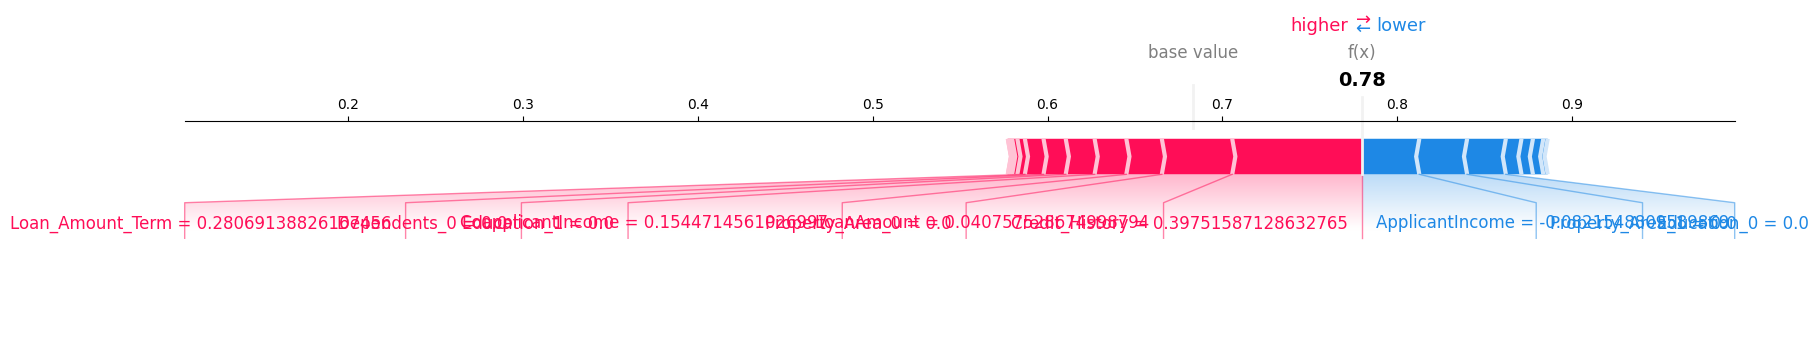

PDF report generated: SHAP_report_samples.pdf


In [51]:
import matplotlib.pyplot as plt
from PIL import Image

# 1️⃣ Save individual SHAP plots as images
for i in range(X_transformed.shape[0]):
    # Waterfall plot
    plt.figure(figsize=(10,6))
    shap.plots.waterfall(shap_values_class1[i], show=False)
    waterfall_path = f"waterfall_sample_{i+1}.png"
    plt.savefig(waterfall_path, bbox_inches='tight')
    plt.close()

    # Force plot
    plt.figure(figsize=(10,6))
    shap.force_plot(
        base_value=shap_values_class1.base_values[i],
        shap_values=shap_values_class1.values[i],
        features=X_transformed[i],
        feature_names=feature_names,
        matplotlib=True   # draws on current figure
    )
    force_path = f"force_sample_{i+1}.png"
    plt.savefig(force_path, bbox_inches='tight')  # save current figure
    plt.close()

# 2️⃣ Combine images into a single PDF using PIL
images = []
for i in range(X_transformed.shape[0]):
    waterfall = Image.open(f"waterfall_sample_{i+1}.png")
    force = Image.open(f"force_sample_{i+1}.png")
    # Optionally resize to same width
    max_width = max(waterfall.width, force.width)
    waterfall = waterfall.resize((max_width, waterfall.height))
    force = force.resize((max_width, force.height))
    images.append(waterfall)
    images.append(force)

pdf_path = "SHAP_report_samples.pdf"
images[0].save(pdf_path, save_all=True, append_images=images[1:])
print(f"PDF report generated: {pdf_path}")


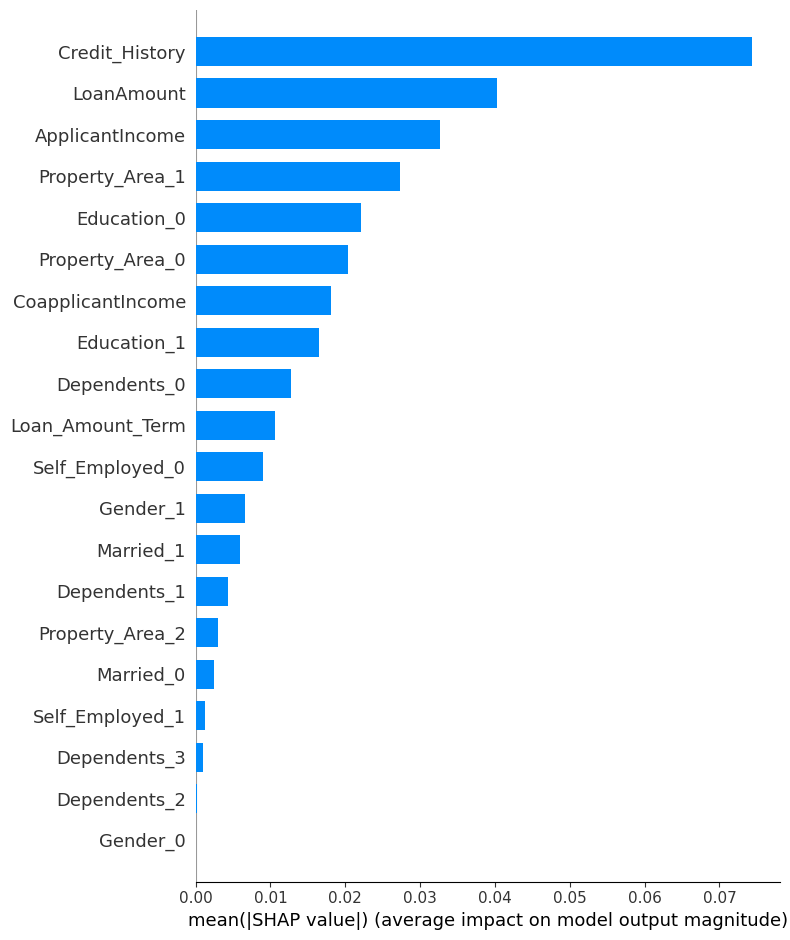

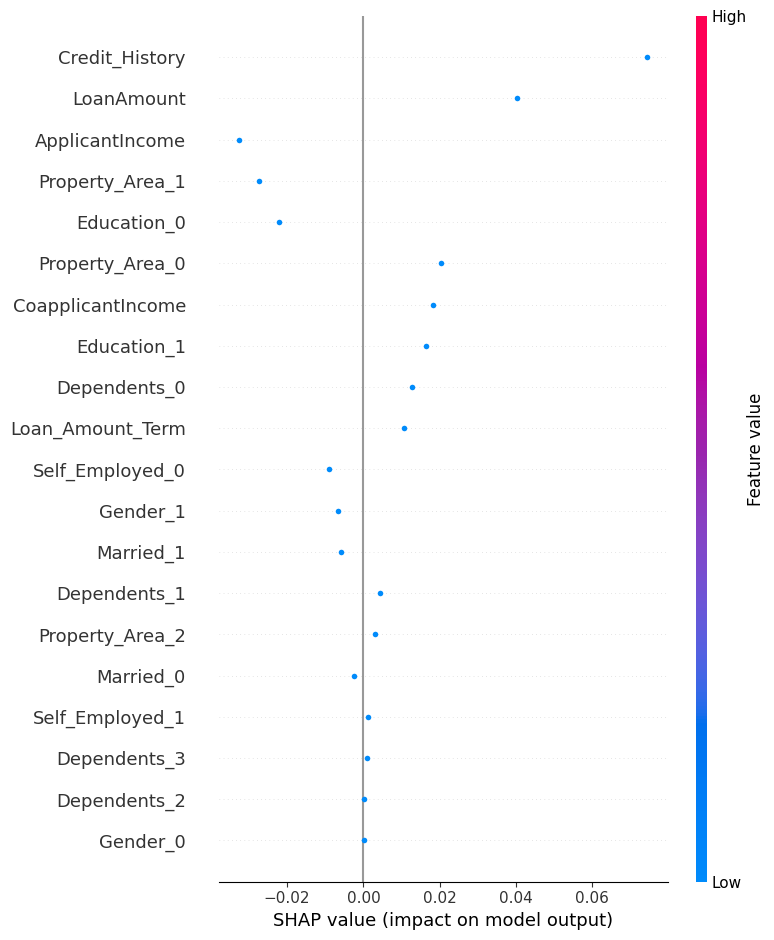

In [52]:
# Bar plot (average absolute SHAP values)
shap.summary_plot(shap_values_class1.values, X_transformed, feature_names=feature_names, plot_type="bar")

# Beeswarm plot (distribution of SHAP values)
shap.summary_plot(shap_values_class1.values, X_transformed, feature_names=feature_names)


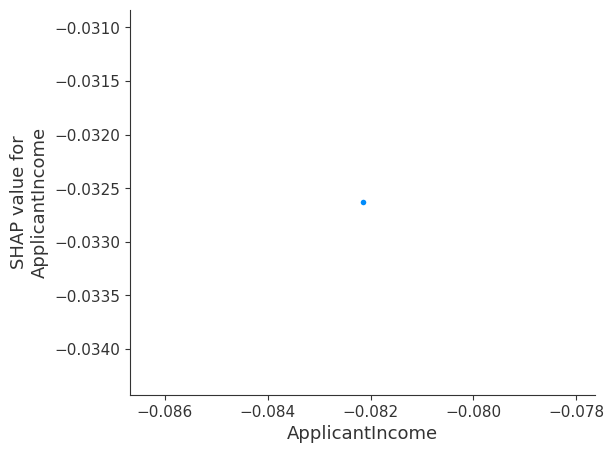

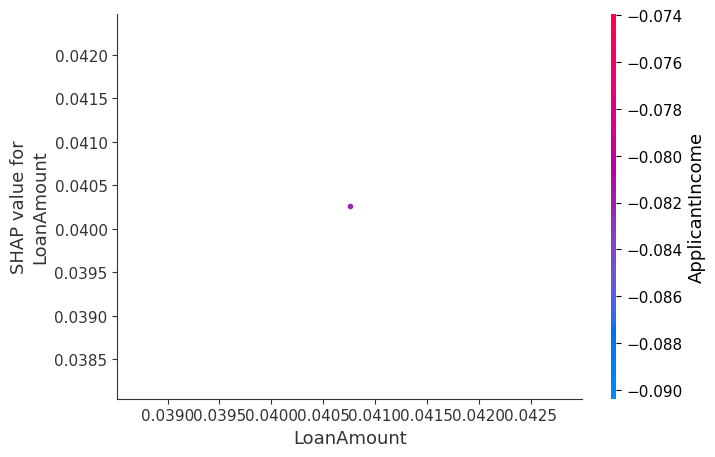

In [53]:
shap.dependence_plot("ApplicantIncome", shap_values_class1.values, X_transformed, feature_names=feature_names)
shap.dependence_plot("LoanAmount", shap_values_class1.values, X_transformed, feature_names=feature_names)


In [54]:
import pandas as pd
shap_df = pd.DataFrame(shap_values_class1.values, columns=feature_names)
shap_df.to_csv("shap_values_all_samples.csv", index=False)


<Figure size 1000x400 with 0 Axes>

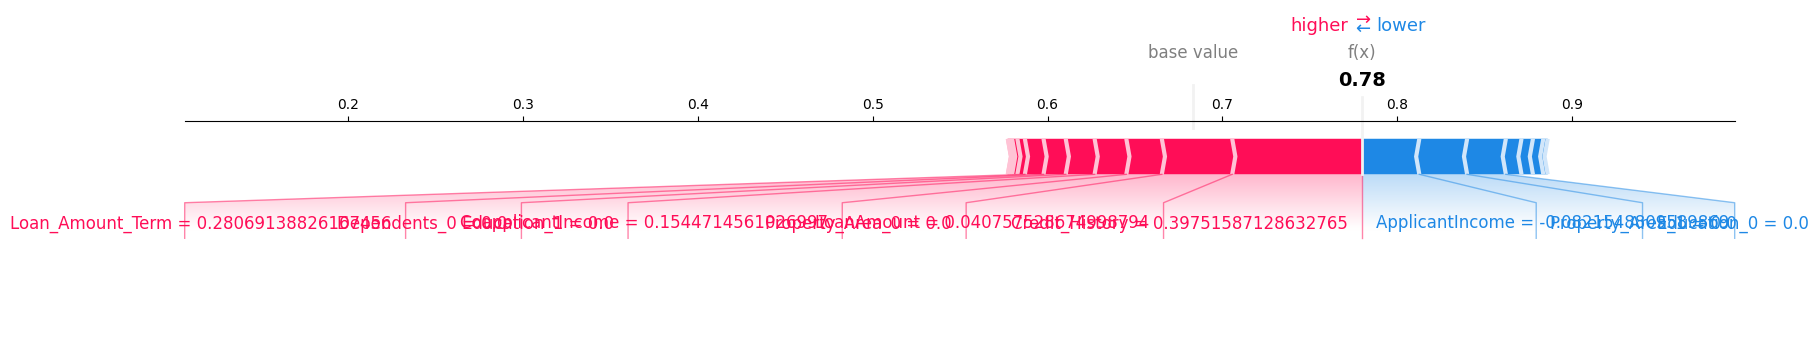

In [55]:
import matplotlib.pyplot as plt
from PIL import Image
import os

report_images = []

for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # ✅ Waterfall plot
    plt.figure(figsize=(10,6))
    shap.plots.waterfall(shap_values_class1[i], show=False)
    waterfall_path = f"waterfall_sample_{sample_id}.png"
    plt.savefig(waterfall_path, bbox_inches='tight')
    plt.close()
    report_images.append(waterfall_path)

    # ✅ Force plot (matplotlib mode)
    plt.figure(figsize=(10,4))
    shap.plots.force(
        shap_values_class1[i],
        matplotlib=True
    )
    force_path = f"force_sample_{sample_id}.png"
    plt.savefig(force_path, bbox_inches='tight')
    plt


In [56]:
images = [Image.open(img) for img in report_images]
pdf_path = "SHAP_report_all_samples.pdf"

# Convert all images to RGB if needed
images_rgb = [img.convert('RGB') for img in images]
images_rgb[0].save(pdf_path, save_all=True, append_images=images_rgb[1:])
print(f"PDF report generated: {pdf_path}")


PDF report generated: SHAP_report_all_samples.pdf


In [59]:
from PIL import Image, ImageDraw, ImageFont
import pandas as pd

top_feature_images = []

for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # Top 5 features for this sample
    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_value": shap_values_class1.values[i]
    }).sort_values(by="SHAP_value", key=abs, ascending=False)
    top_features = shap_df.head(5)

    # Create an image with the table
    table_img = Image.new('RGB', (800, 150), color='white')
    d = ImageDraw.Draw(table_img)

    # Load default font
    font = ImageFont.load_default()

    # Title
    d.text((10, 10), f"Top 5 SHAP Features - Sample {sample_id}", fill='black', font=font)

    # Draw feature rows
    y_offset = 40
    for idx, row in top_features.iterrows():
        text = f"{row['Feature']}: {row['SHAP_value']:.4f}"
        d.text((10, y_offset), text, fill='black', font=font)
        y_offset += 20

    # Append image to list
    top_feature_images.append(table_img)

# Example: save first top-feature image
top_feature_images[0].save("top_features_sample_1.png")


In [60]:
from PIL import Image

# 1️⃣ Collect all images for the PDF
all_images = []

for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # Load top feature table image
    top_feat_img = top_feature_images[i]

    # Load waterfall plot image
    waterfall_path = f"waterfall_sample_{sample_id}.png"  # make sure you've saved these already
    waterfall_img = Image.open(waterfall_path)

    # Load force plot image
    force_path = f"force_sample_{sample_id}.png"          # make sure you've saved these already
    force_img = Image.open(force_path)

    # Optionally resize images to same width for PDF alignment
    max_width = max(top_feat_img.width, waterfall_img.width, force_img.width)
    top_feat_img = top_feat_img.resize((max_width, top_feat_img.height))
    waterfall_img = waterfall_img.resize((max_width, waterfall_img.height))
    force_img = force_img.resize((max_width, force_img.height))

    # Append images in order: top features → waterfall → force
    all_images.extend([top_feat_img, waterfall_img, force_img])

# 2️⃣ Save all images into a single PDF
pdf_path = "SHAP_full_report.pdf"
all_images[0].save(pdf_path, save_all=True, append_images=all_images[1:])
print(f"PDF report generated: {pdf_path}")


PDF report generated: SHAP_full_report.pdf


In [61]:
# 1️⃣ Generate and save SHAP global summary plots
import matplotlib.pyplot as plt

# Bar plot (average absolute SHAP values)
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
summary_bar_path = "summary_bar.png"
plt.savefig(summary_bar_path, bbox_inches='tight')
plt.close()

# Dot plot (beeswarm)
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    show=False
)
summary_dot_path = "summary_dot.png"
plt.savefig(summary_dot_path, bbox_inches='tight')
plt.close()

# 2️⃣ Append summary plots to your existing PDF
from PIL import Image

summary_images = [
    Image.open(summary_bar_path),
    Image.open(summary_dot_path)
]

# Resize summary plots to match PDF width
pdf_width = all_images[0].width
for i in range(len(summary_images)):
    img = summary_images[i]
    summary_images[i] = img.resize((pdf_width, img.height))

# Append to the existing PDF
all_images.extend(summary_images)
pdf_path = "SHAP_full_report_with_summary.pdf"
all_images[0].save(pdf_path, save_all=True, append_images=all_images[1:])
print(f"Full SHAP report PDF (with summary) generated: {pdf_path}")


Full SHAP report PDF (with summary) generated: SHAP_full_report_with_summary.pdf


In [62]:
# 1️⃣ Generate SHAP dependence plots for key numeric features
dependence_images = []

for feature in num_features:  # or select specific features like ['ApplicantIncome', 'LoanAmount']
    plt.figure(figsize=(10,6))
    shap.dependence_plot(
        feature,
        shap_values_class1.values,
        X_transformed,
        feature_names=feature_names,
        show=False
    )
    dep_path = f"dependence_{feature}.png"
    plt.savefig(dep_path, bbox_inches='tight')
    plt.close()

    # Open image and add to list
    dep_img = Image.open(dep_path)
    dep_img = dep_img.resize((pdf_width, dep_img.height))  # resize to PDF width
    dependence_images.append(dep_img)

# 2️⃣ Append dependence plots to the existing PDF
all_images.extend(dependence_images)
final_pdf_path = "SHAP_full_report_with_dependence.pdf"
all_images[0].save(final_pdf_path, save_all=True, append_images=all_images[1:])
print(f"Final SHAP report with dependence plots generated: {final_pdf_path}")


Final SHAP report with dependence plots generated: SHAP_full_report_with_dependence.pdf


In [63]:
import os

# List of all temporary image files
temp_files = []

# Waterfall and force plots
for i in range(X_transformed.shape[0]):
    temp_files.append(f"waterfall_sample_{i+1}.png")
    temp_files.append(f"force_sample_{i+1}.png")

# Dependence plots
for feature in num_features:
    temp_files.append(f"dependence_{feature}.png")

# Delete all temporary files
for file in temp_files:
    if os.path.exists(file):
        os.remove(file)

print("Temporary SHAP plot images cleaned up.")


Temporary SHAP plot images cleaned up.


In [64]:
from IPython.display import IFrame

# Display PDF in notebook
IFrame("SHAP_report_samples.pdf", width=800, height=600)


In [65]:
from IPython.display import FileLink

# Create a clickable download link
FileLink("SHAP_report_samples.pdf")


/content/SHAP_report_samples.pdf

In [66]:
import pandas as pd
import numpy as np

# 1️⃣ Convert SHAP values to DataFrame
shap_df_all = pd.DataFrame(
    shap_values_class1.values,
    columns=feature_names
)

# 2️⃣ Compute average absolute SHAP values for each feature
mean_abs_shap = shap_df_all.abs().mean().sort_values(ascending=False)

# 3️⃣ Display top 5 most important features globally
top_global_features = mean_abs_shap.head(5)
print("Top 5 Global Features by SHAP Importance:\n", top_global_features)

# 4️⃣ Optional: save to CSV
top_global_features.to_csv("top_global_shap_features.csv", header=["mean_abs_shap"])


Top 5 Global Features by SHAP Importance:
 Credit_History     0.074375
LoanAmount         0.040259
ApplicantIncome    0.032630
Property_Area_1    0.027356
Education_0        0.022150
dtype: float64


In [67]:
report_texts = []

for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # Get top 5 features for this sample
    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_value": shap_values_class1.values[i]
    }).sort_values(by="SHAP_value", key=abs, ascending=False)
    top_features = shap_df.head(5)

    # Build textual summary
    text = f"Sample {sample_id} Prediction Explanation:\n"
    for idx, row in top_features.iterrows():
        impact = "increased" if row['SHAP_value'] > 0 else "decreased"
        text += f" - {row['Feature']} {impact} the prediction by {abs(row['SHAP_value']):.4f}\n"

    report_texts.append(text)

# 1️⃣ Print all sample reports
for rpt in report_texts:
    print(rpt)

# 2️⃣ Optionally, save to a text file
with open("shap_text_report.txt", "w") as f:
    for rpt in report_texts:
        f.write(rpt + "\n")


Sample 1 Prediction Explanation:
 - Credit_History increased the prediction by 0.0744
 - LoanAmount increased the prediction by 0.0403
 - ApplicantIncome decreased the prediction by 0.0326
 - Property_Area_1 decreased the prediction by 0.0274
 - Education_0 decreased the prediction by 0.0222



<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

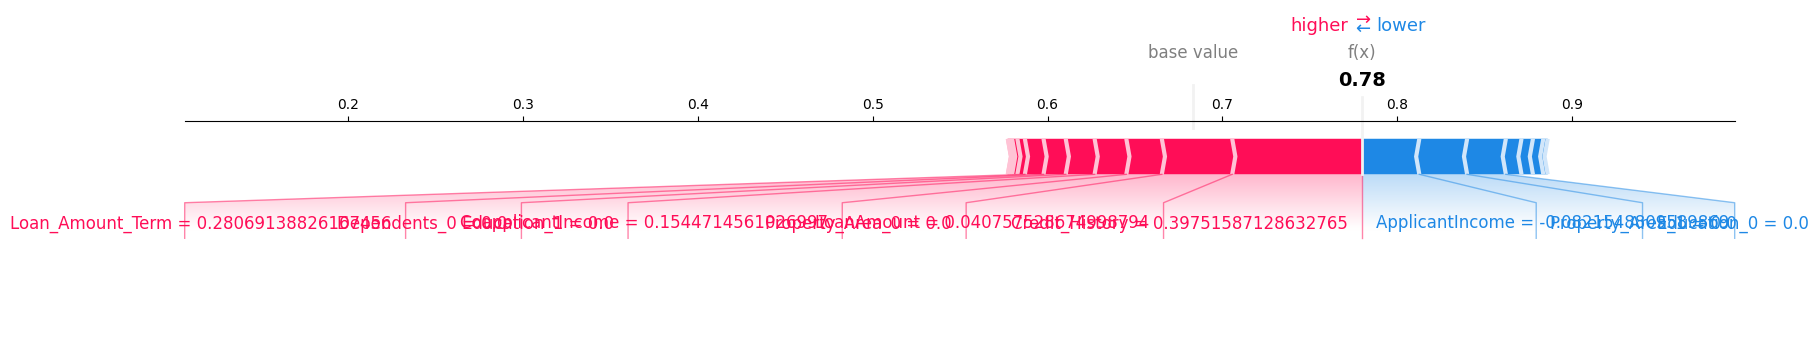

Full SHAP PDF report generated: SHAP_report_full.pdf


In [69]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import pandas as pd
import numpy as np

# Ensure X_transformed, shap_values_class1, feature_names exist

pdf_images = []

for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # 1️⃣ Save Waterfall plot as image
    plt.figure(figsize=(10,6))
    shap.plots.waterfall(shap_values_class1[i], show=False)
    waterfall_path = f"waterfall_sample_{sample_id}.png"
    plt.savefig(waterfall_path, bbox_inches='tight')
    plt.close()

    # 2️⃣ Save Force plot as image
    plt.figure(figsize=(10,4))
    shap.plots.force(
        base_value=shap_values_class1.base_values[i],
        shap_values=shap_values_class1.values[i],
        features=X_transformed[i],
        feature_names=feature_names,
        matplotlib=True
    )
    force_path = f"force_sample_{sample_id}.png"
    plt.savefig(force_path, bbox_inches='tight')
    plt.close()

    # 3️⃣ Open saved images
    waterfall = Image.open(waterfall_path)
    force = Image.open(force_path)

    # 4️⃣ Create textual explanation image
    text_img = Image.new('RGB', (800, 150), color='white')
    draw = ImageDraw.Draw(text_img)
    font = ImageFont.load_default()

    # Top 5 SHAP features
    top_features = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_value": shap_values_class1.values[i]
    }).sort_values(by="SHAP_value", key=abs, ascending=False).head(5)

    draw.text((10,10), f"Sample {sample_id} Top 5 Features:", fill='black', font=font)
    y = 40
    for idx, row in top_features.iterrows():
        impact = "increased" if row['SHAP_value'] > 0 else "decreased"
        draw.text((10, y), f"{row['Feature']} {impact} prediction by {abs(row['SHAP_value']):.4f}", fill='black', font=font)
        y += 20

    # 5️⃣ Append all 3 images for this sample
    pdf_images.extend([waterfall, force, text_img])

# 6️⃣ Save all images as a single PDF
pdf_images[0].save("SHAP_report_full.pdf", save_all=True, append_images=pdf_images[1:])
print("Full SHAP PDF report generated: SHAP_report_full.pdf")


In [70]:
# 1️⃣ Save Global Summary Plot (bar plot)
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
summary_bar_path = "global_summary_bar.png"
plt.savefig(summary_bar_path, bbox_inches='tight')
plt.close()

# 2️⃣ Save Global Summary Plot (dot plot)
plt.figure(figsize=(10,8))
shap.summary_plot(
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    show=False
)
summary_dot_path = "global_summary_dot.png"
plt.savefig(summary_dot_path, bbox_inches='tight')
plt.close()

# 3️⃣ Save example Dependence Plot (e.g., ApplicantIncome)
plt.figure(figsize=(10,6))
shap.dependence_plot(
    "ApplicantIncome",
    shap_values_class1.values,
    X_transformed,
    feature_names=feature_names,
    show=False
)
dependence_path = "dependence_applicantincome.png"
plt.savefig(dependence_path, bbox_inches='tight')
plt.close()

# 4️⃣ Add these global plots to the PDF images list
pdf_images.extend([
    Image.open(summary_bar_path),
    Image.open(summary_dot_path),
    Image.open(dependence_path)
])

# 5️⃣ Save updated PDF with global plots included
pdf_images[0].save("SHAP_report_full_with_global.pdf", save_all=True, append_images=pdf_images[1:])
print("PDF report with global plots generated: SHAP_report_full_with_global.pdf")


PDF report with global plots generated: SHAP_report_full_with_global.pdf


In [72]:
from PIL import Image, ImageDraw, ImageFont

pdf_images = []

# 1️⃣ Prepare images for PDF
for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # Waterfall plot
    waterfall_path = f"waterfall_sample_{sample_id}.png"
    waterfall_img = Image.open(waterfall_path)
    pdf_images.append(waterfall_img)

    # Force plot
    force_path = f"force_sample_{sample_id}.png"
    force_img = Image.open(force_path)
    pdf_images.append(force_img)

# 2️⃣ Optional: Add title page
title_img = Image.new('RGB', (800, 200), color='white')
d = ImageDraw.Draw(title_img)
font = ImageFont.load_default()
d.text((10, 80), "SHAP Analysis Report", fill='black', font=font)
pdf_images.insert(0, title_img)

# 3️⃣ Save PDF (do not close images yet)
final_pdf_path = "SHAP_report_final.pdf"
pdf_images[0].save(final_pdf_path, save_all=True, append_images=pdf_images[1:])
print(f"✅ Final PDF report generated: {final_pdf_path}")

# 4️⃣ Close images after saving
for img in pdf_images:
    img.close()


✅ Final PDF report generated: SHAP_report_final.pdf


In [73]:
import os

# List of temporary images
for i in range(X_transformed.shape[0]):
    waterfall_path = f"waterfall_sample_{i+1}.png"
    force_path = f"force_sample_{i+1}.png"

    if os.path.exists(waterfall_path):
        os.remove(waterfall_path)
    if os.path.exists(force_path):
        os.remove(force_path)

print("✅ Temporary SHAP plot images cleaned up.")


✅ Temporary SHAP plot images cleaned up.


In [74]:
from PIL import Image
import os

# 1️⃣ Collect all images for PDF
pdf_images = []

for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # Check if image files exist
    waterfall_path = f"waterfall_sample_{sample_id}.png"
    force_path = f"force_sample_{sample_id}.png"

    if os.path.exists(waterfall_path):
        pdf_images.append(Image.open(waterfall_path).convert('RGB'))
    if os.path.exists(force_path):
        pdf_images.append(Image.open(force_path).convert('RGB'))

# 2️⃣ Save all images as a single PDF
if pdf_images:
    pdf_output_path = "SHAP_report_final.pdf"
    pdf_images[0].save(pdf_output_path, save_all=True, append_images=pdf_images[1:])
    print(f"✅ Final PDF report generated: {pdf_output_path}")
else:
    print("❌ No images found to generate PDF")


❌ No images found to generate PDF


In [75]:
from PIL import Image
import os

# Step 12: Combine all images into a single PDF
pdf_images = []

for i in range(X_transformed.shape[0]):
    sample_id = i + 1

    # Image paths
    waterfall_path = f"waterfall_sample_{sample_id}.png"
    force_path = f"force_sample_{sample_id}.png"
    top_features_path = f"top_features_sample_{sample_id}.png"  # if you created top features table image

    # Append images if they exist
    for path in [top_features_path, waterfall_path, force_path]:
        if os.path.exists(path):
            pdf_images.append(Image.open(path).convert('RGB'))

# Save as a single PDF
if pdf_images:
    pdf_output_path = "SHAP_report_final.pdf"
    pdf_images[0].save(pdf_output_path, save_all=True, append_images=pdf_images[1:])
    print(f"✅ Final PDF report generated: {pdf_output_path}")
else:
    print("❌ No images found to generate PDF")


✅ Final PDF report generated: SHAP_report_final.pdf
